[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/machine_learning_court.ipynb)

# 👩‍⚖️ ⚖️ Machine Learning Court

This notebook provides base model training code for our three case scenarios:
1. **Loan Approval**
2. **Breast Cancer Misclassification**
3. **Recidivism Prediction**

> ⚠️ This notebook does **not** include XAI techniques (SHAP, LIME, Anchors). You are expected to implement those yourself based on the model and prediction tasks below.





## ⚖️ Case 1: Loan Denial Dispute – UCI Adult Income Dataset
#### 🔍 Scenario

Jane Dow, a 37-year-old professional woman with a Bachelor's degree and full-time executive role, applied for a premium credit product. The bank’s model—trained to predict income level as a proxy for eligibility—classified her as earning ≤$50K, resulting in denial. She disputes the fairness of the decision.

#### 🟥 Prosecution
Evaluate whether the model’s decision may have been influenced by inappropriate or unfair reasoning. Explore whether the explanation aligns with what should be expected in a fair credit decision.

#### 🟦 Defense
Justify the decision based on the model’s learned patterns. Consider how well the explanation supports the classification and whether similar profiles are treated consistently.

In [13]:
# 📦 Case 1: Loan Approval Prediction (Adult Income Dataset)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load Data
from sklearn.datasets import fetch_openml
adult = fetch_openml(name='adult', version=2, as_frame=True)
df = adult.frame

# Clean and preprocess
df = df.dropna()
df = df.copy()
encoders = {}
label_cols = df.select_dtypes(include='category').columns.tolist()

for col in label_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

X = df.drop(["class", "fnlwgt"], axis=1)
y = df["class"].apply(lambda x: 1 if x == '>50K' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train simple RF model
model_adult = RandomForestClassifier(random_state=42)
model_adult.fit(X_train, y_train)
print(classification_report(y_test, model_adult.predict(X_test)))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9045

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045



In [14]:
# 🎯 Focus Instance: Loan Rejection Case (Jane Dow)

jane_encoded = {
    'age': 37,
    'workclass': encoders['workclass'].transform(['Private'])[0],
    'education': encoders['education'].transform(['Bachelors'])[0],
    'marital-status': encoders['marital-status'].transform(['Never-married'])[0],
    'occupation': encoders['occupation'].transform(['Exec-managerial'])[0],
    'relationship': encoders['relationship'].transform(['Not-in-family'])[0],
    'race': encoders['race'].transform(['White'])[0],
    'sex': encoders['sex'].transform(['Female'])[0],
    'hours-per-week': 50,
    'native-country': encoders['native-country'].transform(['United-States'])[0],
    'capital-gain': 0,
    'capital-loss': 0,
    'education-num': 13,
}

jane_df = pd.DataFrame([jane_encoded])
jane_df = jane_df[X_train.columns]
pred = model_adult.predict(jane_df)
print("Prediction for Jane Dow (Loan Eligibility):", "Approved" if pred[0] == 1 else "Denied")


Prediction for Jane Dow (Loan Eligibility): Denied


## 🩺 Case 2: Tumor Misclassification – Breast Cancer Dataset
#### 🔍 Scenario
Patient X received a benign classification from an AI tumor diagnostic tool and was not referred for a biopsy. Months later, the tumor was diagnosed as malignant. The model’s output is now under scrutiny.

#### 🟥 Prosecution
Use explanation tools to evaluate how the model arrived at this decision. Consider whether any key medical indicators might have been overlooked or minimized.

#### 🟦 Defense
Defend the decision with reference to the model’s logic and learned feature importance. Consider how this decision aligns with the broader data trends.

In [4]:
# 🧬 Case 2: Tumor Misclassification (Breast Cancer Dataset)
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

# Load dataset
data = load_breast_cancer()
df_bc = pd.DataFrame(data.data, columns=data.feature_names)
df_bc['target'] = data.target  # 0 = malignant, 1 = benign

# Train/test split
X = df_bc.drop("target", axis=1)
y = df_bc["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model_bc = RandomForestClassifier(random_state=42)
model_bc.fit(X_train, y_train)
print(classification_report(y_test, model_bc.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [5]:
# 🧬 Focus Instance (Tumor Misclassification - Patient X)
focus_instance_bc = pd.DataFrame([{
    "mean radius": 13.80,
    "mean texture": 15.79,
    "mean perimeter": 90.43,
    "mean area": 584.1,
    "mean smoothness": 0.1007,
    "mean compactness": 0.1280,
    "mean concavity": 0.07789,
    "mean concave points": 0.05069,
    "mean symmetry": 0.1662,
    "mean fractal dimension": 0.06566,
    "radius error": 0.4101,
    "texture error": 1.074,
    "perimeter error": 2.635,
    "area error": 40.14,
    "smoothness error": 0.00541,
    "compactness error": 0.02204,
    "concavity error": 0.01664,
    "concave points error": 0.01185,
    "symmetry error": 0.02095,
    "fractal dimension error": 0.004902,
    "worst radius": 16.57,
    "worst texture": 20.86,
    "worst perimeter": 110.3,
    "worst area": 812.4,
    "worst smoothness": 0.1411,
    "worst compactness": 0.3542,
    "worst concavity": 0.2779,
    "worst concave points": 0.1383,
    "worst symmetry": 0.2589,
    "worst fractal dimension": 0.1030
}])

# Run prediction
pred = model_bc.predict(focus_instance_bc)
print("Prediction for Patient X:", "Benign → No Biopsy" if pred[0] == 1 else "Malignant → Action Needed")


Prediction for Patient X: Benign → No Biopsy


## ⚖️ Case 3: Recidivism Risk – COMPAS Dataset
#### 🔍 Scenario
Malik Johnson, a 27-year-old with one prior felony, was flagged as low risk by an AI risk assessment tool and granted parole. Some community stakeholders have questioned whether this was an appropriate classification.

#### 🟥 Prosecution
Examine whether the model may have underestimated risk factors. Use explanation techniques to uncover potential oversights or inconsistencies.

#### 🟦 Defense
Argue that the decision was reasonable based on the model's criteria. Use explanation tools to show which features were most influential and whether the classification aligns with data-driven patterns.

In [12]:
# ⚖️ Case 3: Recidivism Prediction (COMPAS Dataset)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df_compas = pd.read_csv(url)

# Filter relevant columns and preprocess
features = ['age', 'sex', 'race', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree']
df = df_compas[features + ['two_year_recid']].dropna()
df = df[df['c_charge_degree'].isin(['F', 'M'])]

# Encode categorical variables with explicit mappings so profile values are unambiguous
df = df.copy()
df['sex'] = df['sex'].map({'Female': 0, 'Male': 1})
df['race'] = df['race'].map({
    'African-American': 0,
    'Asian': 1,
    'Caucasian': 2,
    'Hispanic': 3,
    'Native American': 4,
    'Other': 5,
})
df['c_charge_degree'] = df['c_charge_degree'].map({'F': 1, 'M': 0})
df = df.dropna()

X = df[features]
y = df['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_compas = RandomForestClassifier(random_state=42)
model_compas.fit(X_train, y_train)
print(classification_report(y_test, model_compas.predict(X_test)))

              precision    recall  f1-score   support

           0       0.66      0.70      0.68       793
           1       0.61      0.56      0.58       650

    accuracy                           0.64      1443
   macro avg       0.63      0.63      0.63      1443
weighted avg       0.64      0.64      0.64      1443



In [13]:
# 🎯 Focus Instance: Recidivism Risk Case (Malik Johnson)
focus_instance_compas = pd.DataFrame([{
    "age": 27,
    "sex": 1,  # Male
    "race": 0,  # African-American
    "priors_count": 1,
    "juv_fel_count": 0,
    "juv_misd_count": 0,
    "juv_other_count": 0,
    "c_charge_degree": 1,  # Felony
}])

pred = model_compas.predict(focus_instance_compas)
print("Prediction for Malik Johnson (Recidivism):", pred)


Prediction for Malik Johnson (Recidivism): [0]


Malik Johnson prediction: No recidivism
Predicted recidivism probability: 0.391
SHAP explanation for Malik:


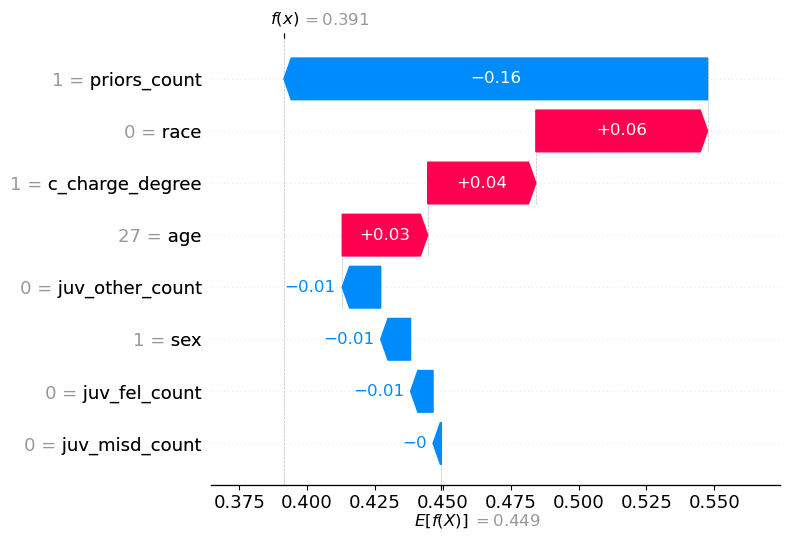

LIME explanation for Malik:
[('0.00 < priors_count <= 2.00', -0.12113449312120317), ('juv_other_count <= 0.00', -0.07372738208494763), ('juv_fel_count <= 0.00', -0.07180504429744017), ('juv_misd_count <= 0.00', -0.05514962626549674), ('25.00 < age <= 31.00', 0.03535403655519852), ('0.00 < c_charge_degree <= 1.00', 0.02581767706290463), ('race <= 0.00', 0.023693835879337054), ('sex <= 1.00', 0.0)]


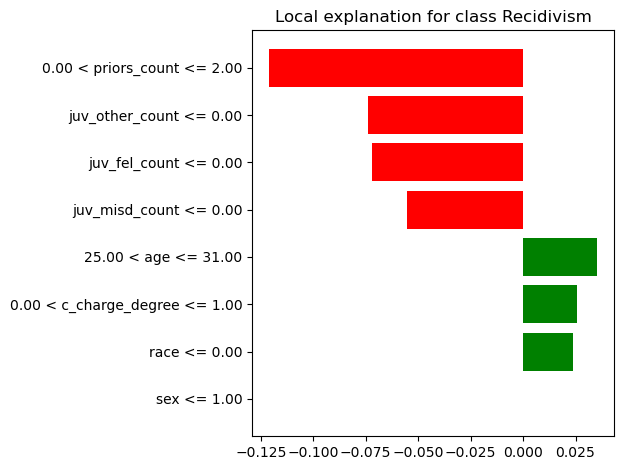

In [15]:
# 🛡️ Defense Explanation: Malik Johnson
# Explain Malik's stated profile with both SHAP and LIME.
import matplotlib.pyplot as plt

malik_instance = focus_instance_compas
malik_prediction = model_compas.predict(malik_instance)[0]
malik_probability = model_compas.predict_proba(malik_instance)[0, 1]

print(
    "Malik Johnson prediction:",
    "Recidivism" if malik_prediction == 1 else "No recidivism",
)
print(f"Predicted recidivism probability: {malik_probability:.3f}")

# SHAP explanation for class 1 (recidivism)
malik_shap_explainer = shap.TreeExplainer(model_compas)
malik_shap_values = malik_shap_explainer.shap_values(malik_instance)

if isinstance(malik_shap_values, list):
    malik_values = malik_shap_values[1][0]
    malik_base_value = malik_shap_explainer.expected_value[1]
else:
    malik_values = (
        malik_shap_values[0, :, 1]
        if malik_shap_values.ndim == 3
        else malik_shap_values[0]
    )
    malik_base_value = (
        malik_shap_explainer.expected_value[1]
        if np.ndim(malik_shap_explainer.expected_value) > 0
        else malik_shap_explainer.expected_value
    )

malik_shap_explanation = shap.Explanation(
    values=malik_values,
    base_values=malik_base_value,
    data=malik_instance.iloc[0].values,
    feature_names=malik_instance.columns.tolist(),
)

print("SHAP explanation for Malik:")
shap.plots.waterfall(malik_shap_explanation, max_display=len(malik_instance.columns), show=False)
plt.tight_layout()
plt.show()

# Keep DataFrame feature names when LIME calls the model.
def predict_malik_proba(values):
    values_with_names = pd.DataFrame(values, columns=malik_instance.columns)
    return model_compas.predict_proba(values_with_names)

# LIME explanation for the same Malik profile
malik_lime_explanation = lime_explainer.explain_instance(
    malik_instance.iloc[0].to_numpy(),
    predict_malik_proba,
    num_features=len(malik_instance.columns),
)

print("LIME explanation for Malik:")
print(malik_lime_explanation.as_list())
malik_lime_explanation.as_pyplot_figure()
plt.tight_layout()
plt.show()

### Model Prediction Summary
Using explicit categorical mappings, the Random Forest predicts Malik's profile as **no recidivism** with a recidivism probability of about `0.391` (39.1%). The model's average baseline probability is about `0.449` (44.9%), so Malik's profile is slightly below the baseline risk. The model has limited predictive performance on this simplified feature set: accuracy is about 64%, and recall for the recidivism class is about 56%.

### SHAP Analysis of Malik's Profile
SHAP (SHapley Additive exPlanations) explains one prediction by starting with the model's average output and then showing how each feature moves that output up or down. In this waterfall plot, the baseline recidivism probability is about `0.449`, and Malik's final predicted probability is about `0.391`.

For Malik, the largest contributions are:

- `priors_count = 1` lowers the predicted risk substantially, by about `-0.16`;
- `race = 0` raises the prediction by about `+0.06` in this model;
- `c_charge_degree = 1` (felony) raises the prediction by about `+0.04`;
- `age = 27` raises the prediction by about `+0.03`; and
- the absence of juvenile offenses slightly lowers the prediction.

The negative contribution from Malik's limited prior record and the small negative contributions from his juvenile-history features outweigh the positive contributions from the encoded race category, felony charge, and age. This moves the prediction modestly below the baseline and results in a no-recidivism classification.

From a defense perspective, the explanation supports a measured argument: the model recognized risk-related factors such as the felony charge and age, but its prediction was lowered primarily by Malik's limited prior record and lack of juvenile offenses. This is an explanation of the model's behavior, not proof that the decision is fair, accurate, or causally justified. The model also has limited predictive performance, so the prediction should not be treated as certain.

The categorical values are explicit codes: African-American is `race = 0`, Male is `sex = 1`, and felony is `c_charge_degree = 1`. These codes identify categories; they are not quantities on a numeric scale.

### LIME Explanation of Malik's Profile
LIME (Local Interpretable Model-agnostic Explanations) explains one prediction by creating many nearby variations of Malik's profile. It observes how the model responds to those variations and fits a simpler local model around Malik's specific case.

The LIME plot's bars are local weights for the class shown in the title, **Recidivism**:

- Red bars push the local approximation away from recidivism, toward no recidivism.
- Green bars push the local approximation toward recidivism.
- Larger absolute bars indicate greater influence in LIME's local approximation.

For Malik, LIME identifies the low prior-count range and the absence of juvenile offenses as the strongest factors lowering the local recidivism estimate. The encoded race category and Malik's age range push the estimate upward, while the felony indicator has only a small positive local weight. The exact LIME weights are approximate and can vary because LIME samples nearby profiles.

### How LIME Differs from SHAP
SHAP and LIME are both local explanation methods, but they work differently. SHAP decomposes the model output into feature contributions relative to a baseline. LIME fits a simpler model near Malik's profile using perturbed examples.

SHAP's waterfall plot shows how the Random Forest moves from about `0.449` to `0.391`. LIME instead gives locally weighted rules that approximate the Random Forest near Malik. SHAP is more directly tied to an additive decomposition of this model output, while LIME is often easier to read as local rules but depends on the perturbation and weighting choices.

The two methods agree that Malik's limited prior record and lack of juvenile offenses reduce predicted risk. They also show that age and the encoded race category increase the local estimate. This agreement supports the defense explanation, but neither method establishes causation or fairness. Because the model includes demographic variables such as race and sex, a separate fairness analysis would still be necessary.